In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv(
    r"D:\DA INTERN\da vs\Sales performance analysis\SuperStoreOrders.csv"
)

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (51290, 21)

Columns:
Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

Missing Values:
order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [9]:
df['order_date'] = pd.to_datetime(
    df['order_date'],
    format='mixed'
)

df['ship_date'] = pd.to_datetime(
    df['ship_date'],
    format='mixed'
)

print("Date conversion successful!")

Date conversion successful!


In [10]:
df['order_date'].head(20)

0    2011-01-01
1    2011-01-01
2    2011-01-01
3    2011-01-01
4    2011-01-01
5    2011-01-01
6    2011-02-01
7    2011-03-01
8    2011-03-01
9    2011-03-01
10   2011-03-01
11   2011-03-01
12   2011-03-01
13   2011-03-01
14   2011-03-01
15   2011-03-01
16   2011-03-01
17   2011-03-01
18   2011-03-01
19   2011-03-01
Name: order_date, dtype: datetime64[ns]

In [11]:
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

df[['sales','profit','quantity','discount']].describe()

,sales,profit,quantity,discount
count,48660.000000,51290.000000,51290.000000,51290.000000
mean,161.017838,28.641740,3.476545,0.142908
std,201.092519,174.424113,2.278766,0.212280
min,0.000000,-6599.978000,1.000000,0.000000
25%,29.000000,0.000000,2.000000,0.000000
50%,77.000000,9.240000,3.000000,0.000000
75%,208.000000,36.810000,5.000000,0.200000
max,999.000000,8399.976000,14.000000,0.850000


In [12]:
print("Missing Sales Values:", df['sales'].isnull().sum())

Missing Sales Values: 2630


In [13]:
df = df.dropna(subset=['sales'])

print("New Shape:", df.shape)

New Shape: (48660, 21)


category
Office Supplies    2790258.0
Technology         2638265.0
Furniture          2406605.0
Name: sales, dtype: float64


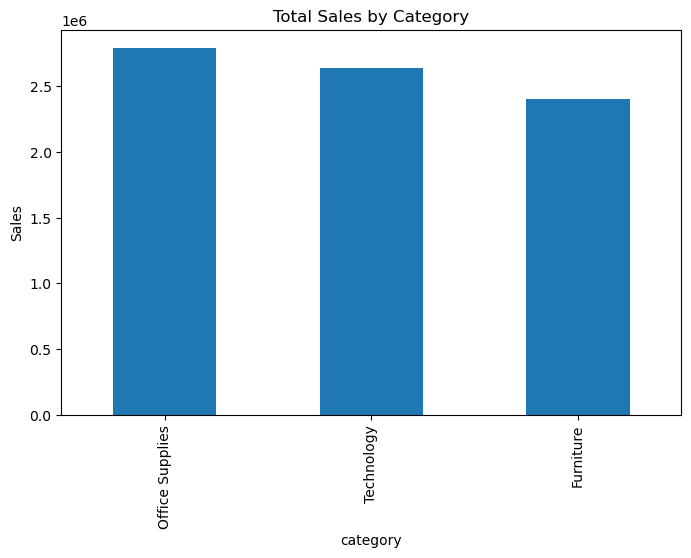

In [14]:
category_sales = df.groupby('category')['sales'].sum().sort_values(ascending=False)

print(category_sales)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')

plt.title("Total Sales by Category")
plt.ylabel("Sales")
plt.show()

category
Office Supplies    350107.32450
Technology         267573.47238
Furniture           97049.37790
Name: profit, dtype: float64


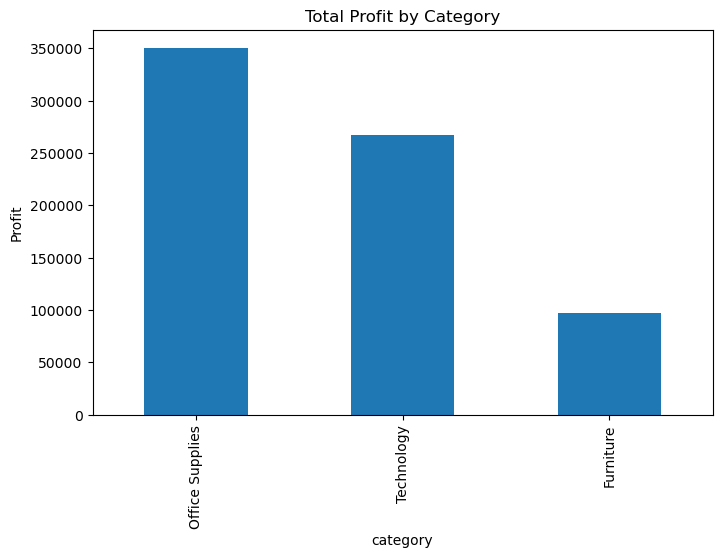

In [15]:
category_profit = df.groupby('category')['profit'].sum().sort_values(ascending=False)

print(category_profit)

plt.figure(figsize=(8,5))
category_profit.plot(kind='bar')

plt.title("Total Profit by Category")
plt.ylabel("Profit")
plt.show()

region
Central           1806638.0
South             1031101.0
North              790546.0
Oceania            625382.0
EMEA               575562.0
Africa             538115.0
Southeast Asia     532172.0
North Asia         453686.0
West               424173.0
Central Asia       389506.0
East               366492.0
Caribbean          251441.0
Canada              50314.0
Name: sales, dtype: float64


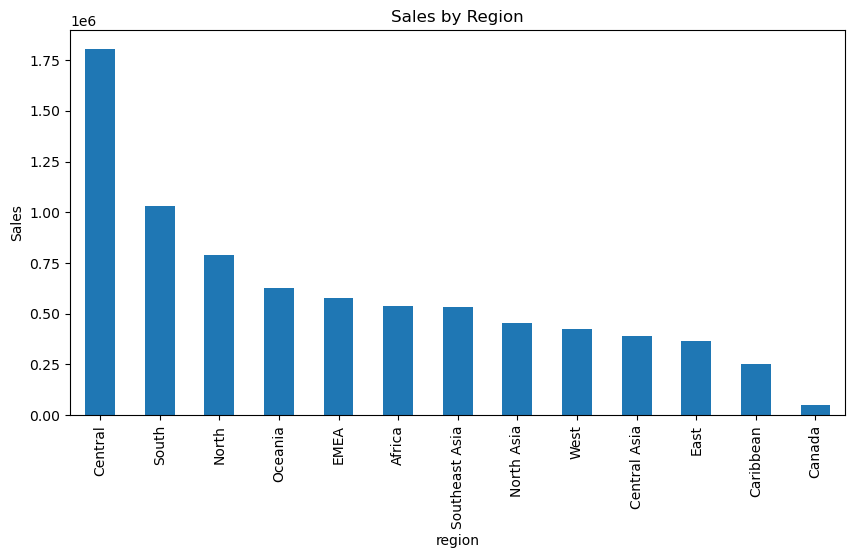

In [16]:
region_sales = df.groupby('region')['sales'].sum().sort_values(ascending=False)

print(region_sales)

plt.figure(figsize=(10,5))
region_sales.plot(kind='bar')

plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

product_name
Eldon File Cart, Single Width                         31319.0
Rogers File Cart, Single Width                        22645.0
Tenex File Cart, Single Width                         20778.0
Smead File Cart, Single Width                         20775.0
Office Star Executive Leather Armchair, Adjustable    19355.0
Fellowes Lockers, Industrial                          19172.0
Smead Lockers, Industrial                             18648.0
Hewlett Copy Machine, Color                           16849.0
Rogers Lockers, Blue                                  16494.0
Fellowes Lockers, Wire Frame                          16470.0
Name: sales, dtype: float64


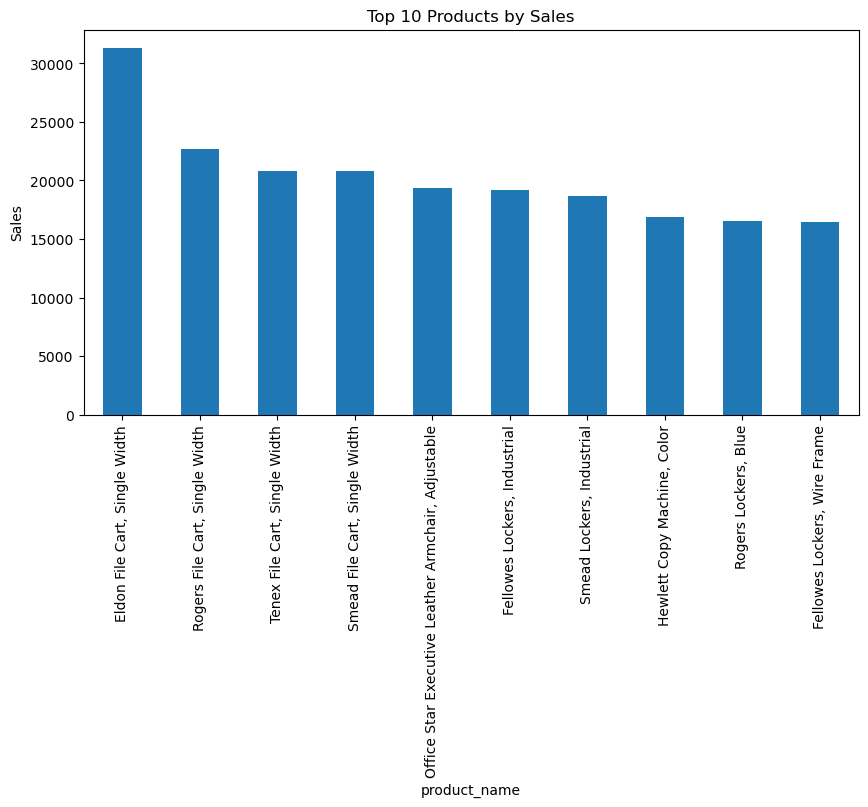

In [17]:
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)

print(top_products)

plt.figure(figsize=(10,5))
top_products.plot(kind='bar')

plt.title("Top 10 Products by Sales")
plt.ylabel("Sales")
plt.show()

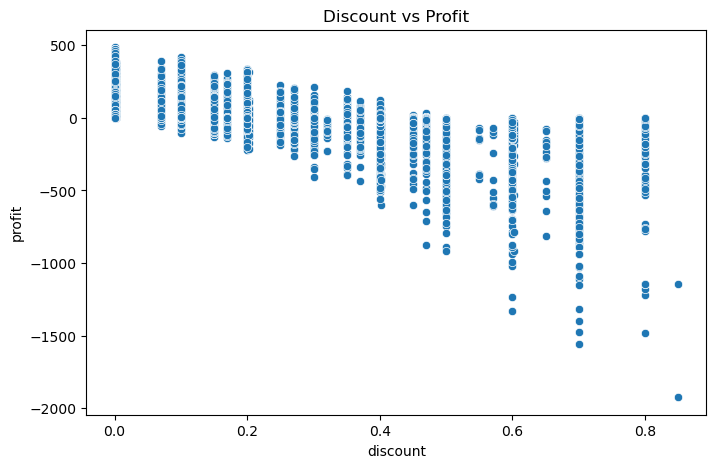

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='discount',
    y='profit'
)

plt.title("Discount vs Profit")
plt.show()

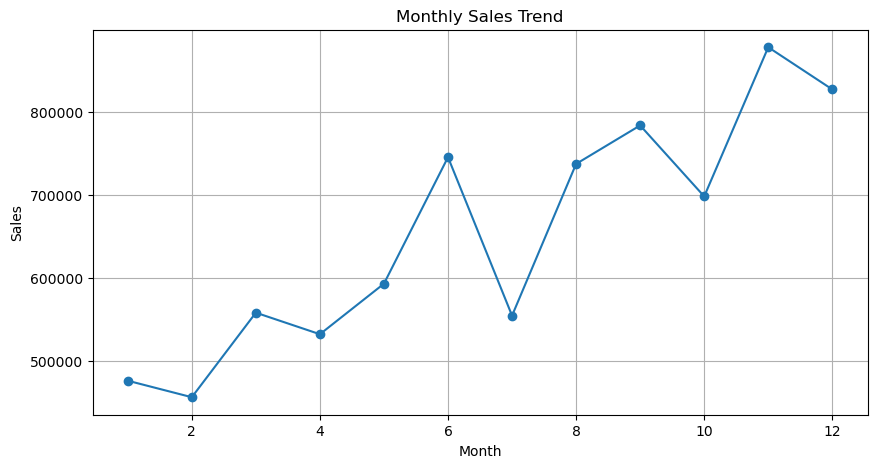

In [19]:
df['month'] = df['order_date'].dt.month

monthly_sales = df.groupby('month')['sales'].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

segment
Consumer       4058118.0
Corporate      2369261.0
Home Office    1407749.0
Name: sales, dtype: float64


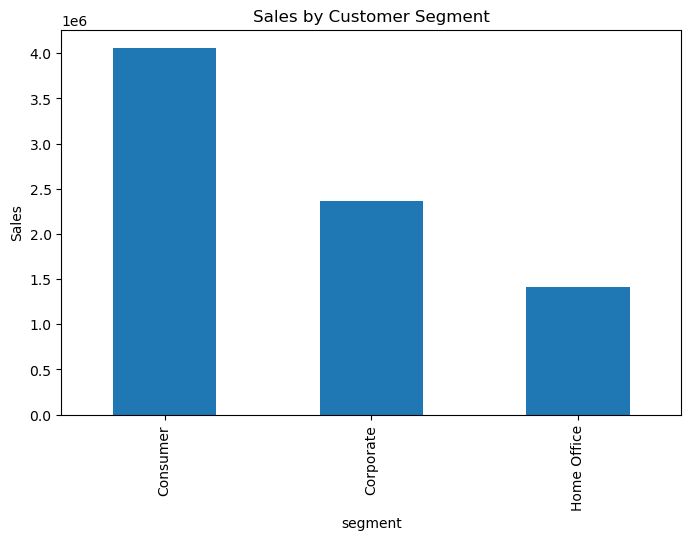

In [20]:
segment_sales = df.groupby('segment')['sales'].sum()

print(segment_sales)

plt.figure(figsize=(8,5))

segment_sales.plot(kind='bar')

plt.title("Sales by Customer Segment")
plt.ylabel("Sales")

plt.show()

In [21]:
print("""
Sales Performance Analysis - Conclusion

1. Office Supplies generated the highest sales and profit.
2. Furniture showed lower profitability despite significant sales.
3. Central region contributed the highest revenue.
4. Consumer customers generated the largest share of sales.
5. Higher discounts negatively impacted profitability.
6. Sales peaked during the final months of the year.

Recommendations:
- Focus on high-performing categories.
- Optimize discount strategies.
- Strengthen weak regional markets.
- Prioritize Consumer segment retention.
- Capitalize on year-end sales opportunities.
""")


Sales Performance Analysis - Conclusion

1. Office Supplies generated the highest sales and profit.
2. Furniture showed lower profitability despite significant sales.
3. Central region contributed the highest revenue.
4. Consumer customers generated the largest share of sales.
5. Higher discounts negatively impacted profitability.
6. Sales peaked during the final months of the year.

Recommendations:
- Focus on high-performing categories.
- Optimize discount strategies.
- Strengthen weak regional markets.
- Prioritize Consumer segment retention.
- Capitalize on year-end sales opportunities.

